## module 3c — plan rendering (seg-controlnet)

a plan is already a segmentation map — canopy blobs colored by layer on a bed — which is
exactly what a pretrained seg controlnet conditions on. sd 1.5 + `control_v11p_sd15_seg`
renders it in 20 denoising steps, no training at all. works on any plan source
(rules, 10's transformer, 11's diffusion).

runtime: one-time ~5.5 gb model download, then ~10 min/image on a 4 gb gtx-16xx card
(fp32 + cpu offload — these cards' fp16 unet emits nan, i.e. black renders, so precision
is auto-selected below; a t4 does ~10 s/image in fp16). 9 renders ≈ 90 min locally,
each with a live step bar. nothing here needs colab — only the future style-lora /
custom-controlnet training does (see the end). (lcm-lora would cut steps 20→4, but its
loader (peft) segfaults against this machine's torch build; on colab add it back.)

In [1]:
# get bvtrain (shared plumbing): locally it's ../bvtrain; on colab/kaggle clone the repo
import os, sys, time
_CANDS = ["..", ".", "botanical-vision"]
if not any(os.path.isdir(f"{p}/bvtrain") for p in _CANDS):
    os.system("git clone -q https://github.com/babnigg/botanical-vision")
sys.path[:0] = [p for p in _CANDS if os.path.isdir(f"{p}/bvtrain")]

import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from bvtrain import garden as g

SEED = 0
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
plt.rcParams["figure.facecolor"] = "linen"
VRAM = torch.cuda.get_device_properties(0).total_memory / 1e9 if torch.cuda.is_available() else 0
f"vram {VRAM:.1f} gb" if VRAM else "cpu"


'vram 4.3 gb'

### conditioning images

`g.seg_image` paints the plan with ade20k-ish colors (grass, earth bed, per-layer canopy)
so the pretrained controlnet reads it semantically without any fine-tuning.

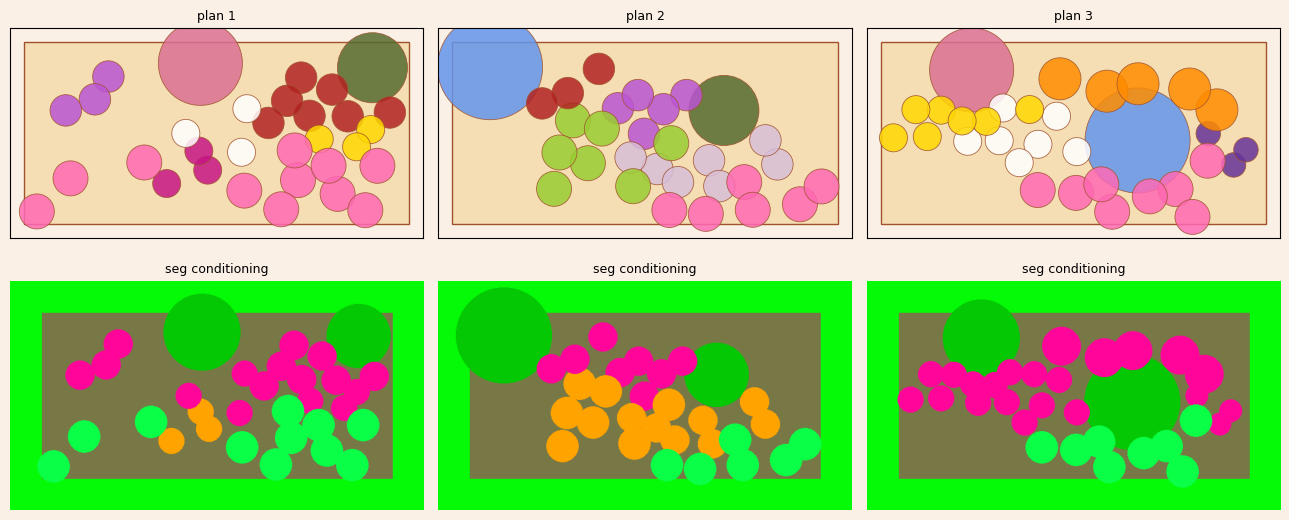

In [2]:
plans = []
for _ in range(3):
    w, d = 5.5, 2.6
    plans.append((g.gen_plan(w, d, sun=2), w, d))

fig, axes = plt.subplots(2, 3, figsize=(13, 5.6))
for k, (plan, w, d) in enumerate(plans):
    g.show_plan(plan, w, d, axes[0][k], f"plan {k + 1}")
    axes[1][k].imshow(g.seg_image(plan, w, d)); axes[1][k].axis("off")
    axes[1][k].set_title("seg conditioning", fontsize=9)
plt.tight_layout()

In [3]:
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel, UniPCMultistepScheduler

# gtx 16xx-class cards produce nan latents in fp16 (black renders) — verified on this
# 1650 ti — so small cards get fp32 + cpu offload; big cards get fast fp16 on-gpu
DTYPE = torch.float16 if VRAM >= 8 else torch.float32
cn = ControlNetModel.from_pretrained("lllyasviel/control_v11p_sd15_seg", torch_dtype=DTYPE)
pipe = StableDiffusionControlNetPipeline.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-v1-5", controlnet=cn,
    torch_dtype=DTYPE, safety_checker=None)
pipe.scheduler = UniPCMultistepScheduler.from_config(pipe.scheduler.config)   # the 7.12 setup
if VRAM and VRAM < 8:
    pipe.enable_model_cpu_offload(); pipe.enable_attention_slicing(); pipe.enable_vae_tiling()
    print(f"low-vram mode: {DTYPE}, cpu offload + attention slicing")
else:
    pipe.to("cuda")

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.controlnet.pipeline_controlnet.StableDiffusionControlNetPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


low-vram mode: torch.float32, cpu offload + attention slicing


C:\Users\daniel\AppData\Roaming\Python\Python312\site-packages\diffusers\pipelines\pipeline_utils.py:2294: FutureWarning: `enable_vae_tiling` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_tiling()` on a `StableDiffusionControlNetPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_tiling()`.
  deprecate(


  0%|          | 0/20 [00:00<?, ?it/s]

  643.2s


  0%|          | 0/20 [00:00<?, ?it/s]

  614.8s


  0%|          | 0/20 [00:00<?, ?it/s]

  608.9s


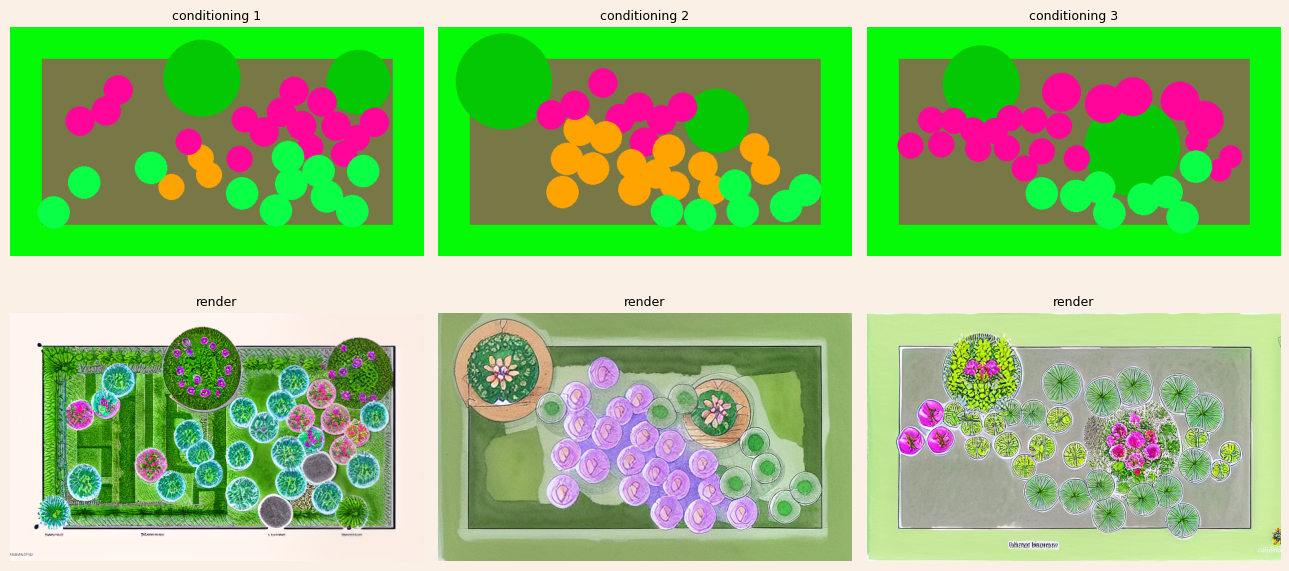

In [4]:
PROMPT = ("top-down garden planting plan, perennial border with flowering shrubs, "
          "lush, watercolor botanical illustration")

def render(plan, w, d, prompt=PROMPT, scale=0.9, seed=0):
    cond = g.seg_image(plan, w, d).resize((640, 384))
    t0 = time.time()
    img = pipe(prompt, image=cond, num_inference_steps=20, guidance_scale=7.0,
               controlnet_conditioning_scale=scale,
               generator=torch.Generator().manual_seed(seed)).images[0]
    print(f"  {time.time() - t0:.1f}s")
    return img

fig, axes = plt.subplots(2, 3, figsize=(13, 6.4))
for k, (plan, w, d) in enumerate(plans):
    axes[0][k].imshow(g.seg_image(plan, w, d)); axes[0][k].axis("off")
    axes[0][k].set_title(f"conditioning {k + 1}", fontsize=9)
    axes[1][k].imshow(render(plan, w, d, seed=k)); axes[1][k].axis("off")
    axes[1][k].set_title("render", fontsize=9)
plt.tight_layout()

### how literally must the render obey the plan?

`controlnet_conditioning_scale` is the knob (the 7.12 ablation, on our domain): 0 ignores
the plan entirely, ~0.9 follows the beds and drifts, >1.2 starts reproducing flat blob
colors instead of plants.

  0%|          | 0/20 [00:00<?, ?it/s]

  579.0s


  0%|          | 0/20 [00:00<?, ?it/s]

  608.5s


  0%|          | 0/20 [00:00<?, ?it/s]

  630.1s


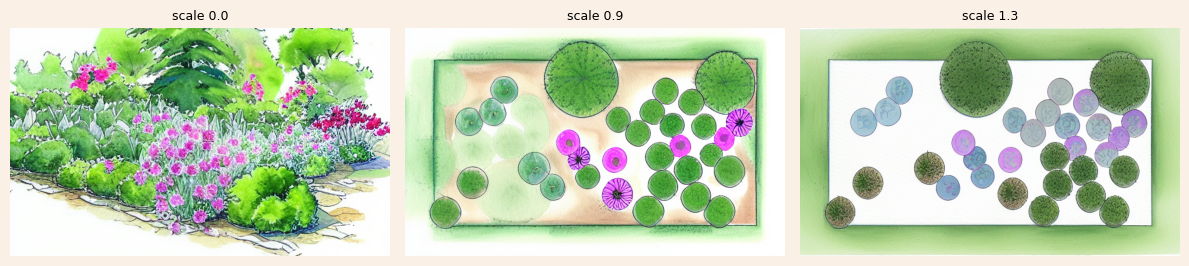

In [5]:
plan, w, d = plans[0]
scales = (0.0, 0.9, 1.3)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
for ax, s in zip(axes, scales):
    ax.imshow(render(plan, w, d, scale=s, seed=7)); ax.axis("off")
    ax.set_title(f"scale {s}", fontsize=9)
plt.tight_layout()

### style is just the prompt

same plan, three looks — and clip similarity (the 7.11/7.13 metric) checks each render
actually matches its prompt, so style choice is measured, not vibes.

  0%|          | 0/20 [00:00<?, ?it/s]

  616.1s


  0%|          | 0/20 [00:00<?, ?it/s]

  620.1s


  0%|          | 0/20 [00:00<?, ?it/s]

  618.2s


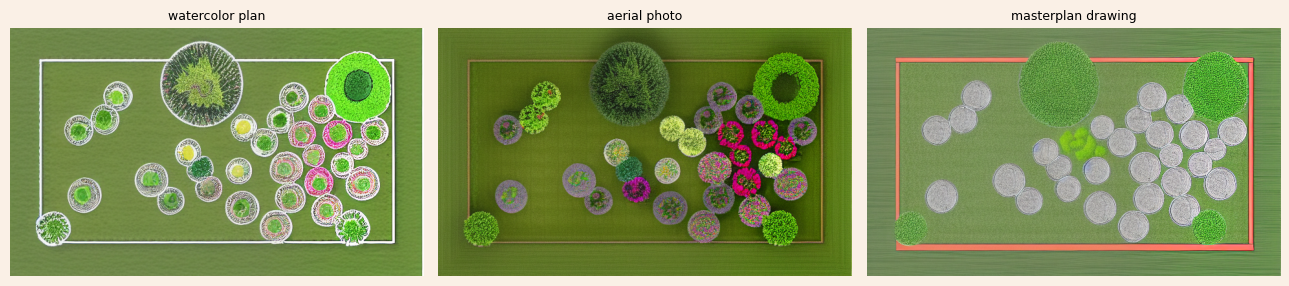

In [6]:
STYLES = {
    "watercolor plan": PROMPT,
    "aerial photo": "aerial photograph of a planted garden border, realistic, "
                    "landscaping, flowering perennials and shrubs, daylight",
    "masterplan drawing": "landscape architecture masterplan drawing, colored pencil "
                          "rendering, garden bed with labeled planting drifts",
}
style_imgs = {}
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, (name, prompt) in zip(axes, STYLES.items()):
    style_imgs[name] = render(plan, w, d, prompt=prompt, seed=11)
    ax.imshow(style_imgs[name]); ax.axis("off"); ax.set_title(name, fontsize=9)
plt.tight_layout()

In [7]:
from transformers import CLIPModel, CLIPProcessor

clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
proc = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
rows = {}
with torch.no_grad():
    for name, prompt in STYLES.items():
        b = proc(text=[prompt], images=style_imgs[name], return_tensors="pt", padding=True, truncation=True)
        i = clip.get_image_features(pixel_values=b["pixel_values"])
        t = clip.get_text_features(input_ids=b["input_ids"], attention_mask=b["attention_mask"])
        rows[name] = float(torch.cosine_similarity(i, t))
pd.Series(rows, name="clip similarity").round(3)

'(ProtocolError('Connection aborted.', RemoteDisconnected('Remote end closed connection without response')), '(Request ID: e573af67-6e31-4c0f-a327-2e7d5bf6db90)')' thrown while requesting HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/config.json


Retrying in 1s [Retry 1/5].


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

watercolor plan       0.255
aerial photo          0.299
masterplan drawing    0.239
Name: clip similarity, dtype: float64

### what would need colab (nothing above does)

- **style lora** on a curated garden-plan image set — ~1 h on a t4 with peft; a 4 gb card
  can't train sd.
- **custom seg controlnet** trained on (seg_image, render) pairs — ~6 h t4, only worth it
  if the pretrained one plateaus.
- **sdxl-quality renders** — inference sits at the 16 gb edge.

### takeaways

- zero-training rendering closes the loop: site → (11) completed plan → styled image.
  scale ~0.9 keeps drifts legible; prompt alone swaps watercolor / photo / masterplan.
- next: hook `sample_plans` (11) straight into this render for an end-to-end compose demo,
  and a style lora once a plan-image set is curated (see the stylize placeholders 08/09).